<a href="https://colab.research.google.com/github/evgenykomarov/sdc_course/blob/spring2026/Prediction_planning_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Установка пакетов и загрузка данных для ноутбука

Для работы нам понадобится установить пакет `waymax` https://github.com/waymo-research/waymax


Waymax -- симулятор для исследования автономного вождения, базирующийся на `Waymo Open Motion Dataset` https://github.com/waymo-research/waymo-open-dataset

Для обучения сетки будем использовать
`Pytorch Lightning` https://lightning.ai/docs/pytorch/

Для запуска на GPU нужно сменить среду выполнения на Графический процессор

Устанавливаем пакеты:

In [2]:
!pip install --upgrade pip
# Install waymax, which will bring in jax and jaxlib (version 0.7.2).
# jaxlib 0.7.2 requires numpy>=2.0.
!pip install git+https://github.com/waymo-research/waymax.git@main#egg=waymo-waymax

# Explicitly install numpy 2.0.0 to satisfy jaxlib's requirement.
# This ensures a numpy 2.x version is used.
!pip install numpy==2.4.4

# Install matplotlib 3.9.0, which is compatible with numpy 2.0.0.
!pip install matplotlib==3.10.9

# pytorch-lightning 2.5.0 is compatible with numpy 2.0.0.
!pip install pytorch-lightning==2.6.1

  Cloning https://github.com/waymo-research/waymax.git (to revision main) to /tmp/pip-install-8kiq55lm/waymo-waymax_2475e845fd944261b57ab9582618c4b0
  Running command git clone --filter=blob:none --quiet https://github.com/waymo-research/waymax.git /tmp/pip-install-8kiq55lm/waymo-waymax_2475e845fd944261b57ab9582618c4b0
  Resolved https://github.com/waymo-research/waymax.git to commit a64dfec9be8576b60d9cecc94f406d9812d4a7d0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Необходимые для семинара данные и код лежат по ссылке https://drive.google.com/drive/folders/1iI_1PIFNx6-5MUIQkjslg1MqRhP7mikM?usp=sharing

Необходимо создать ярлык на своем Google Drive

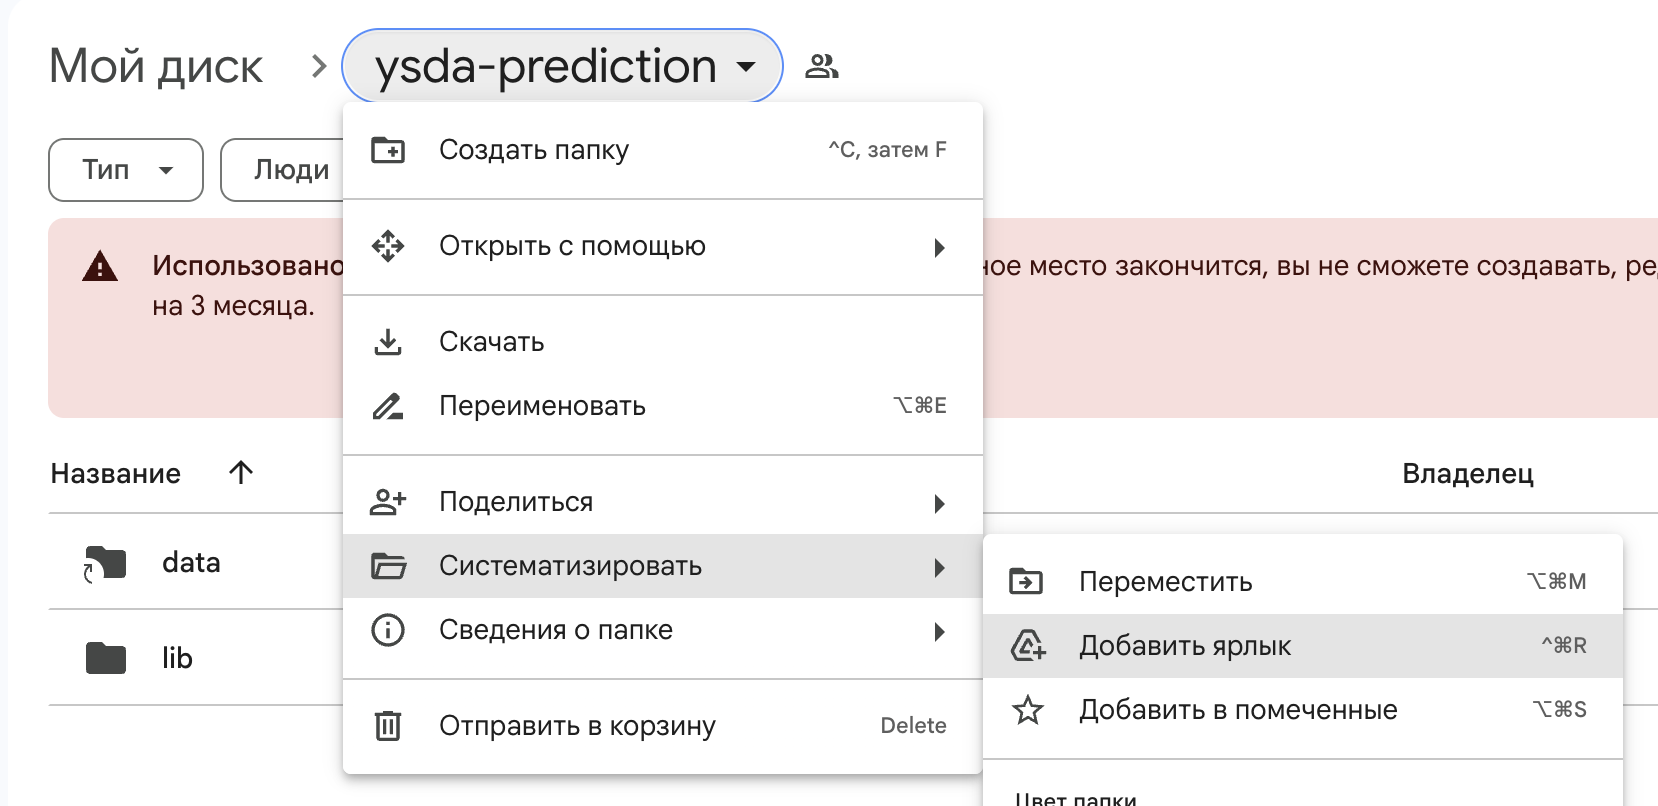

Монтируем гугл диск в локальную файловую систему

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Ниже нужно указать путь до созданного ранее ярлыка, например, если ярлык имеет путь `ai360`, то должно получиться
```
SEMINAR_PATH = '/content/drive/MyDrive/ai360'
```

In [2]:
SEMINAR_PATH = '/content/drive/MyDrive/ysda/self-driving-cars/ysda-prediction'

In [3]:
# !wget -O data.tar.gz "$(curl -s "https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/vHocpJM-oTCj-A" | jq -r .href)"
# # !mkdir ysda-prediction
# !tar -xf data.tar.gz -C '/content/drive/MyDrive/ysda/self-driving-cars/ysda-prediction'

Копируем себе в локальное файловое пространство папки с полезными функциями

In [4]:
import os
import shutil

if not os.path.exists('lib'):
    shutil.copytree(os.path.join(SEMINAR_PATH, 'lib'), 'lib')
else:
    print('"lib" folder already exists. If you want to rewrite lib by original folder, remove local "lib" manually')

"lib" folder already exists. If you want to rewrite lib by original folder, remove local "lib" manually


Импортируем библиотеки

In [5]:
%%capture

import os
from copy import deepcopy
from typing import Any, Optional, Callable, Sequence
from collections import defaultdict
import dataclasses

import shapely

import mediapy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import jax
from jax import numpy as jnp
from jax import random

import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

from waymax.config import DatasetConfig
from waymax import visualization
from waymax import datatypes
from waymax import config as _config
from waymax import dataloader
from waymax import dynamics
from waymax import metrics
from waymax import env as _env
from waymax import agents
from waymax.agents import SimAgentActor, WaymaxActorOutput

import chex

from tqdm import tqdm


from lib.data_utils import WaymaxDataset, scenario_to_features_gt


# Use CUDA for hw
# device = 'cuda'
device = 'cpu'

С помощью следующей функции генерируем конфиг для подгрузки датасета

In [6]:
def get_data_config(split_name, seminar_path=SEMINAR_PATH):
    split_path = os.path.join(SEMINAR_PATH, 'data', split_name)

    obj_count = int(os.listdir(split_path)[0].rsplit('-')[-1])
    return DatasetConfig(
        path=os.path.join(split_path, f'{split_name}_tfexample.tfrecord@{obj_count}'),
        max_num_objects=24,
        batch_dims=[8],
        repeat=1,
        shuffle_buffer_size=64,
        deterministic=False,
        num_shards=1
    )

Создаем датасеты для разных сплитов

In [7]:
train_dataset = WaymaxDataset(get_data_config('training'))
val_dataset = WaymaxDataset(get_data_config('validation'))

In [8]:
FUTURE_STEPS = 30  # Predict 3 seconds,  10Hz frequency

In [9]:
scenario = next(iter(train_dataset))
features, gt = scenario_to_features_gt(scenario)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7e037053dad0>, (leaf_jax_array := getattr(leaf, '__jax_array__', None)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7e037053dad0>, (leaf_jax_array := getattr(leaf, '__jax_array__', None)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7e037b948690>, (f := _DEFAULT_TYPEMAP.get(dtype)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7e037b948690>, (f := _DEFAULT_TYPEMAP.get(dtype)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7e037059b7d0>, (aval := get_aval(a)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7e037059b7d0>, (aval := get_aval(a)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [11]:
features.keys()

dict_keys(['log_trajectory', 'sim_trajectory', 'log_traffic_light', 'object_metadata', 'roadgraph_points', 'agent_to_predict_mask'])

# Задания

## 1. Нормализация сцены [3 балла]

Баллы начисляются бинарно(0 или 3) за прохождение теста

Нужно реализовать функции, позволяющие перевести сцену в локальную систему координат агента, которого предсказываем. Данного агента можно вычленить с помощью маски `agent_to_predict_mask`

In [12]:
features['agent_to_predict_mask'].shape

torch.Size([8, 24])

In [13]:
features['log_trajectory'].keys()

dict_keys(['x', 'y', 'z', 'vel_x', 'vel_y', 'yaw', 'valid', 'timestamp_micros', 'length', 'width', 'height'])

In [14]:
features['sim_trajectory'].keys()

dict_keys(['x', 'y', 'z', 'vel_x', 'vel_y', 'yaw', 'valid', 'timestamp_micros', 'length', 'width', 'height'])

In [15]:
features['log_traffic_light'].keys()

dict_keys(['x', 'y', 'z', 'state', 'lane_ids', 'valid'])

In [16]:
features['roadgraph_points'].keys()

dict_keys(['x', 'y', 'z', 'dir_x', 'dir_y', 'dir_z', 'types', 'ids', 'valid'])

In [17]:
features['log_trajectory']['x'].shape

torch.Size([8, 24, 11])

In [18]:
agent_to_predict_mask = features['agent_to_predict_mask'] # [bs, 24]
agent_to_predict_mask.shape

torch.Size([8, 24])

In [19]:
xs = features['log_trajectory']['x'][..., -1][agent_to_predict_mask]
ys = features['log_trajectory']['y'][..., -1][agent_to_predict_mask]
yaws = features['log_trajectory']['yaw'][..., -1][agent_to_predict_mask]
xs.shape, ys.shape, yaws.shape

(torch.Size([8]), torch.Size([8]), torch.Size([8]))

In [20]:
yaws

tensor([-1.5308e+00,  3.0246e-03,  2.3925e-03,  1.3423e+00, -1.8340e-01,
         2.4888e+00, -1.5601e+00,  2.4725e+00])

Для удобного перевода в систему координат агента сделаем обертку модели, которая нормализует сцену, делает предсказание в новой системе координат и после применяет обратное преобразования для предсказаний.


Реализуйте методы класса

In [24]:
class NormalizeSceneWrapper(nn.Module):
    """
    Wrap model with features normalization and predictions denormalozation
    """

    def __init__(self, model):
        """
        Args:
          model: model to wrap
        """
        super().__init__()
        self.model = model


    @staticmethod
    def extract_anchor_x_y_yaw(features):
        """
        Take anchor coordinates as coordinates of agent to predict in last tick

        Args:
          features: features in global space

        Return:
          anchor: tuple containing (anchor_x, anchor_y, anchor_yaw)
                anchor_x: [bs] x coord of target agent per batch
                anchor_y: [bs] y coord of target agent per batch
                anchor_yaw: [bs] yaw of target agent per batch
        """
        # YOUR CODE HERE
        agent_to_predict_mask = features['agent_to_predict_mask'] # [bs, 24]
        anchor_x = features['log_trajectory']['x'][..., -1][agent_to_predict_mask]
        anchor_y = features['log_trajectory']['y'][..., -1][agent_to_predict_mask]
        anchor_yaw = features['log_trajectory']['yaw'][..., -1][agent_to_predict_mask]
        return anchor_x, anchor_y, anchor_yaw


    @staticmethod
    def affine(x, y, x0, y0, angle):
        assert x.shape[0] == x0.shape[0] # batch_size
        view_shape = [-1] + [1] * (x.ndim - 1)
        x_prime =  (x - x0.view(*view_shape)) * torch.cos(angle).view(*view_shape) + (y - y0.view(*view_shape)) * torch.sin(angle).view(*view_shape)
        y_prime = -(x - x0.view(*view_shape)) * torch.sin(angle).view(*view_shape) + (y - y0.view(*view_shape)) * torch.cos(angle).view(*view_shape)
        return x_prime, y_prime

    @staticmethod
    def inverse_affine(x_prime, y_prime, x0, y0, angle):
        assert x_prime.shape[0] == x0.shape[0] # batch_size
        view_shape = [-1] + [1] * (x_prime.ndim - 1)
        x = x0.view(*view_shape) + x_prime * torch.cos(angle).view(*view_shape) - y_prime * torch.sin(angle).view(*view_shape)
        y = y0.view(*view_shape) + x_prime * torch.sin(angle).view(*view_shape) + y_prime * torch.cos(angle).view(*view_shape)
        return x, y

    @staticmethod
    def affine_inplace(dic, x0_, y0_, angle, mode):
        assert mode in set(['coordinate', 'velocity', 'direction', 'angle'])
        if mode == 'coordinate':
            prefix = ''
            x0, y0 = x0_, y0_
        elif mode == 'velocity':
            prefix = 'vel_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'direction':
            prefix = 'dir_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'angle':
            dic['yaw'] -= angle.view(-1, 1, 1)
            return
        else:
            raise Exception

        x_key = prefix + 'x'
        y_key = prefix + 'y'
        assert x_key in dic
        assert y_key in dic
        dic[x_key], dic[y_key] = NormalizeSceneWrapper.affine(dic[x_key], dic[y_key], x0, y0, angle)


    @staticmethod
    def affine_inverse_inplace(dic, x0_, y0_, angle, mode):
        assert mode in set(['coordinate', 'velocity', 'direction', 'angle'])
        if mode == 'coordinate':
            prefix = ''
            x0, y0 = x0_, y0_
        elif mode == 'velocity':
            prefix = 'vel_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'direction':
            prefix = 'dir_'
            x0, y0 = x0_ * 0.0, y0_ * 0.0
        elif mode == 'angle':
            dic['yaw'] += angle.view(-1, 1, 1)
            return
        else:
            raise Exception

        x_key = prefix + 'x'
        y_key = prefix + 'y'
        assert x_key in dic
        assert y_key in dic
        dic[x_key], dic[y_key] = NormalizeSceneWrapper.inverse_affine(dic[x_key], dic[y_key], x0, y0, angle)

    @staticmethod
    def copy_dict_by_keys(dict_of_tensors, key_debug=None):
        assert isinstance(dict_of_tensors, dict)
        assert all([isinstance(dict_of_tensors[key], torch.Tensor) for key in dict_of_tensors])
        result = dict.fromkeys(dict_of_tensors.keys())
        for key, value in dict_of_tensors.items():
            result[key] = value.clone().detach()
        return result

    @staticmethod
    def transform_features_to_agent_space(features, anchor_x, anchor_y, anchor_yaw):
        """
        Transform features to agent space, using anchor of agent space
        Transform all elements of features, including
        `log_trajectory`, `sim_trajectory`, `log_traffic_light` and `roadgraph_points`


        Args:
          features: features in global space
          anchor_x: [bs] x coord of anchor agent
          anchor_y: [bs] y coord of anchor agent
          anchor_yaw: [bs] yaw of anchor agent

        Return:
          features: features in agent space
        """
        # YOUR CODE HERE
        features_prime = {}
        for key in features.keys():
            if isinstance(features[key], torch.Tensor):
                features_prime[key] = features[key].clone().detach()
                continue
            if isinstance(features[key], datatypes.object_state.ObjectMetadata):
                features_prime[key] = features[key]
                continue

            features_prime[key] = NormalizeSceneWrapper.copy_dict_by_keys(features[key], key_debug=key)

            if 'x' in features_prime[key]:
                mode = 'coordinate'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

            if 'vel_x' in features_prime[key]:
                mode = 'velocity'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

            if 'dir_x' in features_prime[key]:
                mode = 'direction'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

            if 'yaw' in features_prime[key]:
                mode = 'angle'
                NormalizeSceneWrapper.affine_inplace(features_prime[key], anchor_x, anchor_y, anchor_yaw, mode)

        assert set(list(features_prime.keys())) - set(list(features.keys())) == set([])
        for key in features_prime:
            if not hasattr(features_prime[key], 'keys'):
                continue
            assert all([features_prime[key][k].shape == features[key][k].shape for k in features_prime[key].keys()])


        # from pdb import set_trace
        # set_trace()


        return features_prime

    @staticmethod
    def transform_predictions_from_agent_space(pred, anchor_x, anchor_y, anchor_yaw):
        """
        Transform predictions to global space, using anchor of agent space
        Transform all elements of prediction, including
        `/trajectory/x`, `/trajectory/y`, `/trajectory/yaw`,
        `/trajectory/vel_x` and `/trajectory/vel_y`


        Args:
          pred: predictions in agent space, see SimpleModel for format
          anchor_x: [bs] x coord of anchor agent
          anchor_y: [bs] y coord of anchor agent
          anchor_yaw: [bs] yaw of anchor agent

        Return:
          pred: predictions in global space
          pred = {
            'trajectory': {
                'x': traj[..., 0],
                'y': traj[..., 1],
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),
                'vel_x': traj[..., 4],
                'vel_y': traj[..., 5]
            },
          }
        """
        # YOUR CODE HERE
        # TODO: x0 = 0, y0 = 0 for velocity mode
        assert set(list(pred.keys())) == set(['trajectory', 'logits'])
        assert set(list(pred['trajectory'].keys())) == set(['x', 'y', 'vel_x', 'vel_y', 'yaw', ])
        for mode in ['coordinate', 'velocity', 'angle', ]:
            NormalizeSceneWrapper.affine_inverse_inplace(pred['trajectory'], anchor_x, anchor_y, anchor_yaw, mode)

        return pred


    def forward(self, features, *args, **kwargs):
        """
        Transform features to target agent space,
        run model and transform predictions to original space

        Args:
          features: features in global space

        Returns:
          pred: pred of model in global space
        """
        # Select anchor coordinates of local space
        anchor_x, anchor_y, anchor_yaw = NormalizeSceneWrapper.extract_anchor_x_y_yaw(features)

        # Transform features to agent space
        new_features = NormalizeSceneWrapper.transform_features_to_agent_space(
            features,
            anchor_x,
            anchor_y,
            anchor_yaw
        )

        # Run model
        pred = self.model(new_features, *args, **kwargs)

        # Transform predictions from agent space to global space
        pred = NormalizeSceneWrapper.transform_predictions_from_agent_space(
            pred,
            anchor_x,
            anchor_y,
            anchor_yaw
        )

        return pred

In [25]:
from lib.tests.tests import test_normalize_wrapper

Tecт на 3 балла

In [26]:
test_normalize_wrapper(NormalizeSceneWrapper)

Normalize wrapper test passed


Ниже приведена немного измененная модель с семинара и показан пример ее использования вместе со враппером

In [27]:
class SimpleModel(nn.Module):
    def __init__(
            self,
            hidden_dim=128,
            history_size=11,
            n_modes=6,
            future_steps=FUTURE_STEPS
    ):
        """
        Simple model

        """
        super().__init__()
        self.layers = nn.Sequential(
            # x 7 is for ['x', 'y', 'vel_x', 'vel_y', 'length', 'width', 'valid', ]
            # + 1 is for  agent_type (vehicle, pedestrian, cyclist etc)
            nn.Linear(history_size * 7 + 1, hidden_dim),
            nn.ReLU(),
            # x 6 is for ['x', 'y', 'yaw', 'vel_x', 'vel_y', 'valid', ]
            # + n_modes to predict logits for each mode
            nn.Linear(hidden_dim, future_steps * n_modes * 6 + n_modes)
        )
        self.future_steps = future_steps
        self.n_modes = n_modes

    def __call__(self, features):
        bs, n_a, n_t = features['log_trajectory']['x'].shape

        # Make agent history features
        agents_history = torch.stack(
            [
                features['log_trajectory']['x'],
                features['log_trajectory']['y'],
                features['log_trajectory']['vel_x'],
                features['log_trajectory']['vel_y'],
                features['log_trajectory']['length'],
                features['log_trajectory']['width'],
                features['log_trajectory']['valid'],
            ],
            axis=-1
        )

        # Take interesting agent features
        agent_history = agents_history[features['agent_to_predict_mask']]
        agent_history = agent_history.reshape(bs, -1)

        # Add agent_type feature to features
        agent_type = features['object_metadata']['object_types'][features['agent_to_predict_mask']]
        agent_features = torch.cat(
            [agent_history, agent_type[..., None]], dim=-1)


        # Make prediction
        res = self.layers(agent_features)

        logits = res[..., -self.n_modes:]
        traj = res[..., :-self.n_modes].reshape(logits.shape[0], self.n_modes, self.future_steps, 6)

        res = {
            'trajectory': {
                'x': traj[..., 0],
                'y': traj[..., 1],
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),
                'vel_x': traj[..., 4],
                'vel_y': traj[..., 5]
            },
            'logits': logits
        }

        return res

In [28]:
model = NormalizeSceneWrapper(SimpleModel())
res = model(features)

## 2. Генерация растровых фичей [5 баллов]

- PixelTransformer [1 балл]
- AgentRenderer [2 балла]
- RoadGraphRenderer [1 балла]
- TrafficLightRenderer [1 балла]


В данной секции мы хотим взять векторные признаки и превратить их в растровую картинку. Отдельно напишем рендереры для траектории, карты и светофоров

In [29]:
import importlib
import lib.tests.tests
importlib.reload(lib.tests.tests)

from lib.tests.tests import (
    test_agent_renderer,
    test_roadgraph_renderer,
    test_traffic_light_renderer,
    test_pixel_transformer
)

In [30]:
def plot_feature_map(feature_map, batch_idx=2):
    for i in range(feature_map.shape[1]):
        plt.figure(figsize=(10, 10))
        plt.title(f'Channel {i}, empty={feature_map[batch_idx][i].sum() == 0}')
        plt.imshow(-feature_map[batch_idx][i], cmap="gray", origin='lower')
        plt.show()

In [31]:
features, gt = scenario_to_features_gt(scenario, map_points=2048)

Векторизовывать мы будем уже центрированные в интересующем агенте признаки

(Если у Вас не сделан предыдущий пункт, то для дебага можете подгрузить данные из `lib/tests/data/transformed_features`)

In [32]:
ego_space_features = NormalizeSceneWrapper.transform_features_to_agent_space(
    features,
    *NormalizeSceneWrapper.extract_anchor_x_y_yaw(features)
)

Для начала реализуем класс, который будет переводить координаты в векторных фичах в координату пикселя на фичемапе. Предлагается пользоваться им для написания всех рендереров

In [62]:
class PixelTransformer:
    def __init__(self, size, resolution):
        """
        Transform coordinates between ordinary coordinates and feature map pixel index

        Args:
          size: length and width of feature map in pixels
          resolution: length and width of every pixel in meters


        """

        self.size = size
        self.resolution = resolution

        self.center_pixel = size // 2

        self.BIG_VALUE = (size // 2) * resolution
        self.OTHER_BIG_VALUE = size

    @staticmethod
    def linear(x, x0, y0, x1, y1):
        """
        rescales x s.t. y(x1) == x1 and y(x0) == y0
        y(x) = y1 + (x - x1) * (y1 - y0) / (x1 - x0)
        """
        return y1 + (x - x1) * (y1 - y0) / (x1 - x0)

    def to_pixel(self, x, y):
        """
        Transform from ordinary coordinates to feature map pixel index
        Assume (x=0, y=0) -> (ix=self.center_pixel, iy=self.center_pixel)
        Assume (x=-BIG_VALUE, y=-BIG_VALUE) -> (ix=-OTHER_BIG_VALUE, iy=-OTHER_BIG_VALUE)

        Args:
          x: x coordinates of arbitrary shape
          y: y coordinates of arbitrary shape

        Return:
          tuple with two elements `(ix, iy)` where ix and iy are coordinates on feature map
        """

        # YOUR CODE HERE
        center = self.center_pixel
        ix = PixelTransformer.linear(x, 0, center, -self.BIG_VALUE, -self.OTHER_BIG_VALUE)
        iy = PixelTransformer.linear(y, 0, center, -self.BIG_VALUE, -self.OTHER_BIG_VALUE)

        return torch.round(ix), torch.round(iy)

    def to_coord(self, ix, iy):
        """
        Transform from feature map pixel index to ordinary coords
        Assume (ix=self.center_pixel, iy=self.center_pixel) -> (x=0, y=0)
        Assume (ix=-OTHER_BIG_VALUE, iy=-OTHER_BIG_VALUE) -> (x=-BIG_VALUE, y=-BIG_VALUE)

        Args:
          ix: x pixel indices of arbitrary shape
          iy: y pixel indices of arbitrary shape

        Return:
          tuple with two elements `(x, y)` where x and y are ordinary coordinates
        """
        # YOUR CODE HERE
        center = self.center_pixel
        x = PixelTransformer.linear(ix, center, 0, -self.OTHER_BIG_VALUE, -self.BIG_VALUE)
        y = PixelTransformer.linear(iy, center, 0, -self.OTHER_BIG_VALUE, -self.BIG_VALUE)

        return x, y

    def to_clipped_pixel(self, x, y):
        """
        Transform from ordinary coordinates to feature map pixel index
        Assume that (x=0, y=0) -> (ix=self.center_pixel, iy=self.center_pixel)
        Assume (x=-BIG_VALUE, y=-BIG_VALUE) -> (ix=0, iy=0)

        If pixel coordinates ix or iy is out of range for feature map
        clip coords to closest valid value

        Args:
          x: x coordinates of arbitrary shape
          y: y coordinates of arbitrary shape

        Return:
          tuple with two elements `(ix, iy)` where ix and iy are clipped coordinates on feature map
        """
        # YOUR CODE HERE
        ix, iy = self.to_pixel(x, y)
        ix = torch.clamp(ix, min=0, max=self.OTHER_BIG_VALUE - 1)
        iy = torch.clamp(ix, min=0, max=self.OTHER_BIG_VALUE - 1)

        return ix, iy

    def is_valid_coords(self, x, y):
        """
        Check if feature map pixel index after transform
        is inside feature map range
        Assume that (x=0, y=0) -> (mask=True)
        Assume (x=-BIG_VALUE, y=-BIG_VALUE) -> (mask=False)


        Args:
          x: x coordinates of arbitrary shape
          y: y coordinates of arbitrary shape

        Return:
          mask that indicate if coord has valid index on feature map
        """
        ix, iy = self.to_pixel(x, y)
        valid_mask = (ix > 0) & (ix < self.OTHER_BIG_VALUE)
        valid_mask &= (iy > 0) & (iy < self.OTHER_BIG_VALUE)

        # # failed
        # valid_mask = (x > -self.BIG_VALUE) & (x < self.BIG_VALUE)
        # valid_mask &= (y > -self.BIG_VALUE) & (y < self.BIG_VALUE)

        # failed
        # valid_mask = (x > -self.BIG_VALUE) & (x <= self.BIG_VALUE)
        # valid_mask &= (y > -self.BIG_VALUE) & (y <= self.BIG_VALUE)

        # failed
        # valid_mask = (x >= -self.BIG_VALUE) & (x < self.BIG_VALUE)
        # valid_mask &= (y >= -self.BIG_VALUE) & (y < self.BIG_VALUE)

        # failed
        # valid_mask = (x >= -self.BIG_VALUE) & (x <= self.BIG_VALUE)
        # valid_mask &= (y >= -self.BIG_VALUE) & (y <= self.BIG_VALUE)

        return valid_mask

Тест на 1 балл

In [63]:
test_pixel_transformer(PixelTransformer)

AssertionError: /is_valid_coords: tensors not close

In [49]:
from pdb import pm
pm()

> /content/lib/tests/tests.py(28)compare_data()
     26         assert isinstance(y, torch.Tensor), f'{key}: first type {type(x)}, second type {type(y)}'
     27 
---> 28         assert torch.isclose(x, y, rtol=1e-3, atol=1e-3).all(), f'{key}: tensors not close'
     29 
     30 

ipdb> u
> /content/lib/tests/tests.py(15)compare_data()
     13 
     14         for k in x.keys():
---> 15             compare_data(x[k], y[k], f'{key}/{k}')
     16 
     17     if isinstance(x, list):

ipdb> x.keys()
dict_keys(['to_pixel', 'to_clipped_pixel', 'is_valid_coords', 'to_coord'])
ipdb> print(k)
is_valid_coords
ipdb> q


Далее нужно реализовать код рендерера агентов. Детали, которые нужно учесть:
- На выходе метода `__call__` получиться тензор резмера `[bs, 13, size_x, size_y]`
- Заполняем ячейки `res[batch_idx, :, ix, iy]`, если координата, соответствующая `ix, iy` (то есть полученная как `pixel_transformer.to_coord(ix, iy)` лежит внутри обрамляющего прямоугольника агента)
- Cписок каналов `[1.0, x, y, vel_x, vel_y, sin(yaw), cos(yaw), is_sdc, type==0, type==1, type==2, type==3, type==4]`, то есть первый канал константа, а в конце one_hot от тензора `object_metadata/object_types`
- Данный рендерер требует много вычислений, поэтому нужно написать его эффективно, чтобы иметь возможность обрабатывать батчи на лету. Чтобы сделать эффективно предлагается использовать по максимуму векторные операции и следующий порядок вычислений(он необязателен, и, возможно, не самый оптимальный, но гарантирует приемлимое время вычислений)
  - с помощью векторных операций собрать тензор с `state_vector` для всех агентов и посчитать углы обрамляющих прямоугольников всех агентов
  - перебрать все сцены в батче и всех агентов
  - для каждого агента находим диапазон пикселей для перебора (берем максимальные и минимальные координаты среди углов обрамляющего прямоугольника агента и превращаем в индексы пикселей, тем самым получив диапазон перебора)
  - перебираем пиксели и получаем список координат  в оригинальных координатах, соответствующих пикселям-кандидатам на заполнение
  - проверяем полученный список координат-кандидатов на пересечение с прямоугольником агента. Для проверки пересечения с прямоугольником использовать shapely следующим образом. Создать `shapely.Polygon` для углов агента. Создать список точек `shapely.points` из точек, полученных из пикселей(именно сразу встроенный список точек, а не питоновский список объектов `shapely.Point`). Одним вызовом проверить пересечение полигона агента со всеми точками-кандидатами
  - Всем пикселям, имеющим пересечение с агентом, за один вызов присвоить соответствующий `state_vector`

In [ ]:
class AgentRenderer:
    """
    Render agents last tick on feature map

    Args:
      size: length and width of feature map in pixels
      resolution: length and width of pixel in meters
    """

    def __init__(
            self,
            size=400,
            resolution=0.25):

        self.num_types = 5 # for `/object_metadata/object_types` one hot
        self.size = size
        self.resolution = resolution
        self.pixel_transformer = PixelTransformer(size, resolution)

    def __call__(self, features):
        """
        Render features

        Args:
          features: input features

        Return:
          feature_map: torch.tensor of shape [bs, num_channels, self.size, self.size]

        For every pixel (ix, iy) that covered by agent boubding box (means center of pixel is inside bounding box)
        we set `res[batch_idx, :, ix, iy] = state_vector`, where state_vector is
        [1.0, x, y, vel_x, vel_y, sin(yaw), cos(yaw), is_sdc, *one_hot(type)]
        """

        # YOUR CODE HERE

        return res

Референсное решение для `AgentRenderer` работает ~200-250мс в колабе, если ваша реализация медленнее, то обучение в следующем пункте замедлится


In [ ]:
%%time
agent_map = AgentRenderer(size=400, resolution=0.25)(ego_space_features)

In [ ]:
plot_feature_map(agent_map)

Тест на 2 балла

In [ ]:
test_agent_renderer(AgentRenderer)

Далее нужно написать рендерер дорожного графа
- На выходе метода `__call__` получиться тензор резмера `[bs, 26, size_x, size_y]`
- Cписок каналов `[1.0, x, y, dir_x, dir_y, type==0, type==1, ..., type==20]`, то есть первый канал константа, а в конце one_hot от тензора `roadgraph_points/types`
- Для каждого элемента карты ставим на фичемапу `state_vector` только в одну координату `(ix, iy)`, cоответствующую `(x, y)` из карты
- Используйте векторные операции без цикла по элементам карты

In [ ]:
class RoadGraphRenderer:
    def __init__(
            self,
            size=400,
            resolution=0.25):

        self.num_types = 21
        self.channels_size = self.num_types + 5
        self.size = size
        self.resolution = resolution
        self.pixel_transformer = PixelTransformer(size, resolution)

    def __call__(self, features):
        # YOUR CODE HERE

        return res

Референсное решение для `RoadGraphRenderer` работает ~100-150мс в колабе, если ваша реализация медленнее, то обучение в следующем пункте замедлится


In [ ]:
%%time
roadgraph_map = RoadGraphRenderer(size=400, resolution=0.25)(ego_space_features)

In [ ]:
plot_feature_map(roadgraph_map)

Тест на 1 балл




In [ ]:
test_roadgraph_renderer(RoadGraphRenderer)

Далее нужно написать рендерер светофором, аналогично дорожному графу
- На выходе метода `__call__` получиться тензор резмера `[bs, 12, size_x, size_y]`
- Cписок каналов `[1.0, x, y, state==0, state==1, ..., state==8]`, то есть первый канал константа, а в конце one_hot от тензора `log_traffic_light/state`
- Для каждого светофора ставим на фичемапу `state_vector` только в одну координату `(ix, iy)`, cоответствующую `(x, y)` из карты
- `state_vector` содержит состояние в последний тик
- Используйте векторные операции без цикла по элементам карты

In [ ]:
class TrafficLightsRenderer:
    def __init__(
            self,
            size=400,
            resolution=0.25):

        self.num_states = 9
        self.channels_size = 3 + self.num_states
        self.size = size
        self.resolution = resolution
        self.pixel_transformer = PixelTransformer(size, resolution)

    def __call__(self, features):
        # YOUR CODE HERE

        return res

Референсное решение для `TrafficLightsRenderer` работает ~40-60мс в колабе, если ваша реализация медленнее, то обучение в следующем пункте замедлится

In [ ]:
%%time
trl_map = TrafficLightsRenderer(size=400, resolution=0.25)(ego_space_features)

In [ ]:
plot_feature_map(trl_map)

Тест на 1 балл


In [ ]:
test_traffic_light_renderer(TrafficLightsRenderer)

Функция, объединяющая все рендереры

In [ ]:
def render_features(features, size=400, resolution=0.25):
    renderers = [
        AgentRenderer(size=size, resolution=resolution),
        RoadGraphRenderer(size=size, resolution=resolution),
        TrafficLightsRenderer(size=size, resolution=resolution)
    ]

    return torch.cat(
        [
            renderer(features)
            for renderer in renderers
        ],
        dim=1
    )

In [ ]:
map = render_features(ego_space_features)

### Вcпомогательные функции отрисовки предсказаний модели

In [ ]:
def plot_states(states, use_log_traj=False, batch_idx=0):
    imgs = []
    for state in states:
        imgs.append(visualization.plot_simulator_state(
            state, use_log_traj=use_log_traj, batch_idx=batch_idx))
    mediapy.show_video(imgs, fps=10)


def extract_best_mode_from_pred_component(pred, best_mode):
    return pred[np.arange(best_mode.shape[0]), best_mode]

def extract_first_timestep_from_pred(pred):
    return pred[..., 0]


# generate open loop prediction with single model run
def generate_open_loop(model, scenario, history_size=11, agent_idx=None):
    states = []

    # some tensors for slicing
    batch_range = jnp.arange(scenario.object_metadata.is_sdc.shape[0])
    control_mask = scenario.object_metadata.is_sdc
    if agent_idx:
        control_mask = jnp.zeros_like(control_mask)
        control_mask = control_mask.at[batch_range, agent_idx].set(True)
        print(f'Control agent with agent_idx = {agent_idx}')
    else:
        print(f'Control ego agent')
    control_indices = control_mask.argmax(-1)

    features, gt = scenario_to_features_gt(
        scenario,
        agent_to_predict_mask=control_mask,
        device=device
    )

    model.to(device)

    # run model
    pred = model(features)  # YOUR CODE HERE
    state = scenario

    # get best mode
    best_mode = pred['logits'].argmax(-1)  # YOUR CODE HERE

    # get best by logit predictions and convert to numpy
    new_x = extract_best_mode_from_pred_component(pred['trajectory']['x'], best_mode).detach().cpu().numpy()
    new_y = extract_best_mode_from_pred_component(pred['trajectory']['y'], best_mode).detach().cpu().numpy()
    new_vel_x = extract_best_mode_from_pred_component(pred['trajectory']['vel_x'], best_mode).detach().cpu().numpy()
    new_vel_y = extract_best_mode_from_pred_component(pred['trajectory']['vel_y'], best_mode).detach().cpu().numpy()
    new_yaw = extract_best_mode_from_pred_component(pred['trajectory']['yaw'], best_mode).detach().cpu().numpy()


    # make 10 steps to make step.timestep equal to first inference timestep
    state = datatypes.update_state_by_log(state, num_steps=10)
    assert (state.timestep == 10).all()


    for _ in range(FUTURE_STEPS):
        # copy log trajectories to sim trajectories for all objects
        state = datatypes.update_state_by_log(state, num_steps=1)

        # rewrite ego sim_trajectory by predictions
        state.sim_trajectory.x = state.sim_trajectory.x.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_x) # YOUR CODE HERE
        state.sim_trajectory.y = state.sim_trajectory.y.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_y)
        state.sim_trajectory.yaw = state.sim_trajectory.yaw.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_yaw)
        state.sim_trajectory.vel_x = state.sim_trajectory.vel_x.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_vel_x)
        state.sim_trajectory.vel_y = state.sim_trajectory.vel_y.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_vel_y)

        state.sim_trajectory.valid = state.sim_trajectory.valid.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(True)

        states.append(state)

    return states

## 3. Prediction модель [5 баллов]

Здесь мы хотим реализовать модель для предсказания агентов, использующую растровые признаки в качестве признаков карты, то есть здесь запрещено использовать векторные признаки карты и светофоров при обучении модели. При этом можно использовать векторные признаки агентов

- Реализация метрик [1 балл]
- Качество модели [4 балла]
  - min_ade=1.5, top1_ade=3.0 [4 баллов]
  - min_ade=1.7, top1_ade=3.5 [2 баллов]

Модель должна предсказывать 6 мод по 3 секунды и иметь формат выхода аналогичный с SimpleModel

Нужно приложить обучающие кривые (можно скрины) и вывод метрик на валидации


Для начала реализуем функцию подсчета метрик, нас интересуют `top1_ade` и `min_ade` для предсказываемого агента. Не забудьте учесть маску видимости агента в гт, усредняем только те таймстемпы, в которые агент наблюдался

In [ ]:
def prediction_metrics(pred, gt):
    """
    Compute loss for first mode

    Args:
      pred: prediction
      gt: target

    Returns:
      loss: dict with keys `min_ade`, `top1_ade`
    """
    # YOUR CODE HERE
    agent_to_predict_mask = gt['agent_to_predict_mask']

    return {
        'min_ade':
        'top1_ade':
    }

In [ ]:
features, gt = scenario_to_features_gt(scenario)
model = NormalizeSceneWrapper(SimpleModel())
pred = model(features)
prediction_metrics(pred, gt)

In [ ]:
from lib.tests.tests import test_metrics

Тест на 1 балл

In [ ]:
test_metrics(prediction_metrics)

Ниже класс, который будем использовать для обучения моделек

In [ ]:
class PredictionModule(pl.LightningModule):
    """
    Module with methods for model training
    """
    def __init__(
        self,
        model,
        loss_components_function,
        metrics_function,
        training_shift_random_generator=lambda : 0,
        training_agent_sampler=lambda scenario: scenario.object_metadata.is_sdc,
        validation_agent_sampler=lambda scenario: scenario.object_metadata.is_sdc,
        map_points=256,
        lr=1e-3
    ):
        """
        Args:
          model: model to train
          loss_components_function:
            function that takes (pred, gt) and return dict of losses
          metrics_function:
            function that takes (pred, gt) and return dict of metrics
          training_shift_random_generator:
            function that return shift for features/gt split
            it allow us to augment dataset and get more diverse scenarios
          training_agent_sampler: function that return mask with agent of interes during training
          validation_agent_sampler: function that return mask with agent of interes during validation
        """
        super().__init__()
        self.model = model
        self.loss_components_function = loss_components_function
        self.metrics_function = metrics_function
        self.training_shift_random_generator = training_shift_random_generator
        self.training_agent_sampler = training_agent_sampler
        self.validation_agent_sampler = validation_agent_sampler

        self.map_points = map_points
        self.lr = lr

    # Method to log loss
    def log_loss(self, split_name, loss, loss_components, batch_size):
        """
        Log loss to tensorboard

        Args:
          split_name: train/val
          loss: step loss
          loss_components: dict of step loss components
          batch_size: batch_size
        """
        self.log(
            f'{split_name}/epoch/loss/loss',
            loss.detach().cpu().item(),
            batch_size=batch_size,
            on_epoch=True,
            on_step=False
        )
        for k, v in loss_components.items():
            self.log(
                f'{split_name}/epoch/loss/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    # Method to log metrics
    def log_metrics(self, split_name, metrics, batch_size):
        """
        Log metrics to tensorboard

        Args:
          split_name: train/val
          metrics: dict of step metrics
          batch_size: batch_size
        """
        for k, v in metrics.items():
            self.log(
                f'{split_name}/epoch/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    # Model step
    def step(self, scenario, agent_to_predict_mask, shift=0):
        """
        Make model step

        Args:
          scenario: train/val
          agent_to_predict_mask: mask with agent to predict
          shift: shift for features

        Returns:
          (
            pred,            # model output
            gt,              # target
            loss,            # loss value
            loss_components  # loss components dict
          )
        """
        # split scenario to features and gt
        features, gt = scenario_to_features_gt(
            scenario,
            map_points=self.map_points,
            features_first_timestamp=shift,
            agent_to_predict_mask=agent_to_predict_mask,
            device=self.device)
        # apply model
        pred = self.model(features)
        # compute losses
        loss_components = self.loss_components_function(pred, gt)
        loss = sum(loss_components[key] for key in loss_components.keys())
        return pred, gt, loss, loss_components

    # Validation step
    @torch.no_grad
    def validation_step(self, scenario, batch_idx):
        """
        Make validation step

        Args:
          scenario: train/val
          batch_idx: number of step

        Returns:
          loss
        """
        # sample agent to predict
        agent_to_predict_mask = self.validation_agent_sampler(scenario)

        pred, gt, loss, loss_components = self.step(
            scenario,
            agent_to_predict_mask=agent_to_predict_mask)
        self.log_loss(
            'val', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        self.log_metrics(
            'val', self.metrics_function(pred, gt),
            batch_size=scenario['log_trajectory']['x'].shape[0],)

        return loss

    # Training step
    def training_step(self, scenario, batch_idx):
        """
        Make training step

        Args:
          scenario: train/val
          batch_idx: number of step

        Returns:
          loss
        """
        # sample agent to predict
        agent_to_predict_mask = self.training_agent_sampler(scenario)

        pred, gt, loss, loss_components = self.step(
            scenario,
            agent_to_predict_mask=agent_to_predict_mask,
            shift=self.training_shift_random_generator())
        self.log_loss(
            'train', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        return loss

    # Make optimizer
    def configure_optimizers(self):
        """
        Create optimizer

        Returns:
          optimizer
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

Ниже функции выбора агента на сцене для предсказания

In [ ]:
# Sampler for prediction training, use different agents on different epochs
def random_agent_sampler(scenario):
    valid = np.asarray(scenario.log_trajectory.valid[..., 10]).copy()
    valid[scenario.object_metadata.is_sdc] = False
    agent_to_predict_mask = np.argmax(np.random.rand(*valid.shape) * valid, -1)
    mask = np.zeros(scenario.object_metadata.is_sdc.shape, dtype=bool)
    mask[np.arange(agent_to_predict_mask.shape[0]), agent_to_predict_mask] = True
    return jnp.asarray(mask)


# Sampler for prediction validation, use fixed first agent to predict
def first_agent_sampler(scenario):
    valid = np.asarray(scenario.log_trajectory.valid[..., 10]).copy()
    valid[scenario.object_metadata.is_sdc] = False
    agent_to_predict_mask = np.argmax(valid, -1)
    mask = np.zeros(scenario.object_metadata.is_sdc.shape, dtype=bool)
    mask[np.arange(agent_to_predict_mask.shape[0]), agent_to_predict_mask] = True
    return jnp.asarray(mask)


# Sampler for planning, use ego to predict
def ego_agent_sampler(scenario):
    return scenario.object_metadata.is_sdc

Реализуйте модель, которая принимает на вход растровые признаки и обучите ее

In [ ]:
class PredictionModel(nn.Module):
    def __init__(self, n_modes=6, future_steps=30):
        """
        Args:
          model: model to wrap
        """
        super().__init__()
        self.n_modes = n_modes
        self.future_steps = future_steps

        # YOUR CODE HERE


    def forward(self, features):
        # YOUR CODE HERE
        feature_map = render_features(features)

Реализуйте лоссы

In [ ]:
def prediction_loss(pred, gt):
    """
    Compute loss for first mode

    Args:
      pred: prediction
      gt: target

    Returns:
      loss: dict with loss
    """

    # YOUR CODE HERE

    return {

    }


In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=tb_logs/

In [ ]:
prediction_model = NormalizeSceneWrapper(PredictionModel(future_steps=FUTURE_STEPS))

prediction = PredictionModule(
    model=prediction_model,
    loss_components_function=prediction_loss,
    metrics_function=prediction_metrics,
    training_shift_random_generator=lambda : 0,  # use 0 because agent can be invalid in other frames
    training_agent_sampler=random_agent_sampler,
    validation_agent_sampler=first_agent_sampler,
    lr=5e-4,
    map_points=2048
)
prediction = prediction.to(device)
logger = TensorBoardLogger("tb_logs", name="prediction_model")

trainer = pl.Trainer(logger=logger, log_every_n_steps=1, gradient_clip_val=0.5)

In [ ]:
trainer.fit(model=prediction, train_dataloaders=train_dataset, val_dataloaders=val_dataset)

In [ ]:
trainer.validate(model=prediction, dataloaders=val_dataset)

In [ ]:
# predict agent with idx == 1
states = generate_open_loop(prediction.model, scenario, agent_idx=1)

In [ ]:
plot_states(states, batch_idx=0)

In [ ]:
plot_states(states, batch_idx=1)

## 4. Planning модель [7 баллов]

Реализуйте модель, которая использует векторное представление карты для планирования эго-траектории. Для обработки светофоров можно использовать cross_attention светофоров на контролируемые лейны.

Модель должна предсказывать 6 мод по 3 секунды и иметь формат выхода аналогичный с SimpleModel

Таргетные метрики на валидации:
- min_ade=0.6, top1_ade=1.5 [7 баллов]
- min_ade=0.7, top1_ade=1.75 [5 баллов]
- min_ade=0.8, top1_ade=2.0 [3 балла]

Нужно приложить обучающие кривые (можно скрины) и вывод метрик на валидации

Сохраните чекпоинт для следующей ДЗ

In [ ]:
class PlanningModel(nn.Module):
    def __init__(self, n_modes=6, future_steps=30):
        """
        Args:
          model: model to wrap
        """
        super().__init__()
        self.n_modes = n_modes
        self.future_steps = future_steps

        # YOUR CODE HERE


    def forward(self, features):
        # YOUR CODE HERE

In [ ]:
model = NormalizeSceneWrapper(PlanningModel(future_steps=FUTURE_STEPS))
pred = model(features)

Реализуйте лосс


In [ ]:
def planner_loss(pred, gt):
    """
    Compute loss for first mode

    Args:
      pred: prediction
      gt: target

    Returns:
      loss: dict with loss
    """

    # YOUR CODE HERE

    return {

    }


In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=tb_logs/

Инициализируем модуль и тренера

In [ ]:
planner_model = NormalizeSceneWrapper(PlanningModel(future_steps=FUTURE_STEPS))

planner = PredictionModule(
    model=planner_model,
    loss_components_function=planner_loss,
    metrics_function=prediction_metrics,
    training_shift_random_generator=lambda : np.random.randint(0, 80 - FUTURE_STEPS + 1),
    training_agent_sampler=ego_agent_sampler,
    validation_agent_sampler=ego_agent_sampler,
    lr=5e-4
)
planner = planner.to(device)
logger = TensorBoardLogger("tb_logs", name="planner_model")

trainer = pl.Trainer(logger=logger, log_every_n_steps=1, gradient_clip_val=0.5)

Запускаем обучение

In [ ]:
trainer.fit(model=planner, train_dataloaders=train_dataset, val_dataloaders=val_dataset)

In [ ]:
trainer.validate(model=planner, dataloaders=val_dataset)

In [ ]:
# predict ego
states = generate_open_loop(planner.model, scenario)

In [ ]:
plot_states(states, batch_idx=0)

In [ ]:
plot_states(states, batch_idx=1)